In [ ]:
# write program to classify AMNIST handwritten digit dataset using neural netwoks

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers,  models, callbacks
import matplotlib.pyplot as plt

(x_train, y_train),(x_test, y_test)=tf.keras.datasets.mnist.load_data()

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [ ]:
print(x_train[10])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  42 118 219 166 118 118   6
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 103 242 254 254 254 254 254  66
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  18 232 254 254 254 254 254 238
   70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 104 244 254 224 254 254 254
  141   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 207 254 210 25

In [ ]:
# to normalize the data
x_train = x_train/255

# to flatten to (60000, 784) and store in new variable x_train_f
x_train_f = x_train.reshape(x_train.shape[0], -1)

x_test_f = x_test.reshape(x_test.shape[0], -1)

print(x_train_f.shape)

(60000, 784)


In [ ]:
print(x_train_f[260])

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         

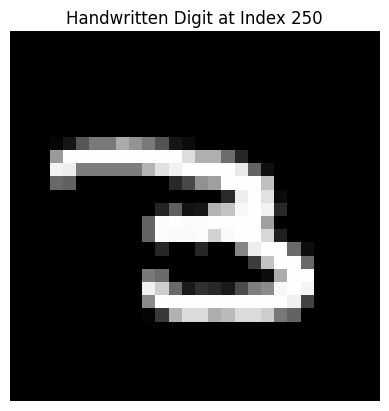

In [ ]:
plt.imshow(x_train[250], cmap='gray')
plt.title(f"Handwritten Digit at Index 250")
plt.axis('off') # Hide pixel coordinates
plt.show()

In [ ]:
model = models.Sequential([
layers.Dense(8, activation="relu", input_shape=(784,)),
layers.Dense(8, activation="relu"),
layers.Dense(8, activation="relu"),
layers.Dense(10, activation="softmax")])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
chk_point=callbacks.ModelCheckpoint(
    filepath="best_model.h5",
    save_best_only=True,
    monitor="val_accuracy",
    mode="max",
    verbose=1
)

history = model.fit(
    x_train_f, y_train,
    validation_data=(x_test_f, y_test),
    epochs = 10,
    batch_size = 32,
    callbacks=[chk_point]
)

Epoch 1/10
1867/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5048 - loss: 1.3851
Epoch 1: val_accuracy improved from None to 0.85520, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7072 - loss: 0.8862 - val_accuracy: 0.8552 - val_loss: 59.2609
Epoch 2/10
1857/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8824 - loss: 0.4010
Epoch 2: val_accuracy improved from 0.85520 to 0.88610, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8877 - loss: 0.3853 - val_accuracy: 0.8861 - val_loss: 52.3021
Epoch 3/10
1863/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9028 - loss: 0.3303
Epoch 3: val_accuracy did not improve from 0.88610
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9064 - loss: 0.3237 - val_accuracy: 0.8830 - val_loss: 58.0554
Epoch 4/10
1858/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9138 - loss: 0.3016
Epoch 4: val_accuracy improved from 0.88610 to 0.89600, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9154 - loss: 0.2927 - val_accuracy: 0.8960 - val_loss: 54.4474
Epoch 5/10
1862/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9224 - loss: 0.2716
Epoch 5: val_accuracy improved from 0.89600 to 0.90280, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9218 - loss: 0.2733 - val_accuracy: 0.9028 - val_loss: 50.9888
Epoch 6/10
1851/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9237 - loss: 0.2650
Epoch 6: val_accuracy did not improve from 0.90280
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9246 - loss: 0.2607 - val_accuracy: 0.8989 - val_loss: 52.9035
Epoch 7/10
1860/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9277 - loss: 0.2509
Epoch 7: val_accuracy improved from 0.90280 to 0.90350, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9277 - loss: 0.2525 - val_accuracy: 0.9035 - val_loss: 51.8315
Epoch 8/10
1852/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9302 - loss: 0.2417
Epoch 8: val_accuracy did not improve from 0.90350
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9296 - loss: 0.2462 - val_accuracy: 0.9025 - val_loss: 52.4891
Epoch 9/10
1870/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9314 - loss: 0.2392
Epoch 9: val_accuracy did not improve from 0.90350
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9310 - loss: 0.2404 - val_accuracy: 0.8852 - val_loss: 65.1379
Epoch 10/10
1873/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9296 - loss: 0.2397
Epoch 10: val_accuracy did not improve from 0.90350
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9311 - loss: 0.2369 - val_accuracy: 0.9035 - val_loss: 53.0305


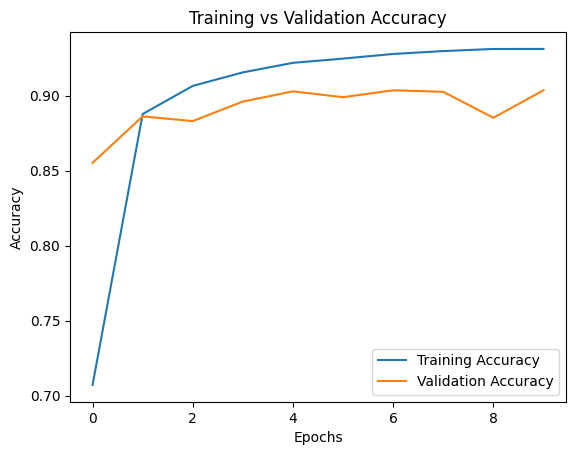

In [ ]:
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

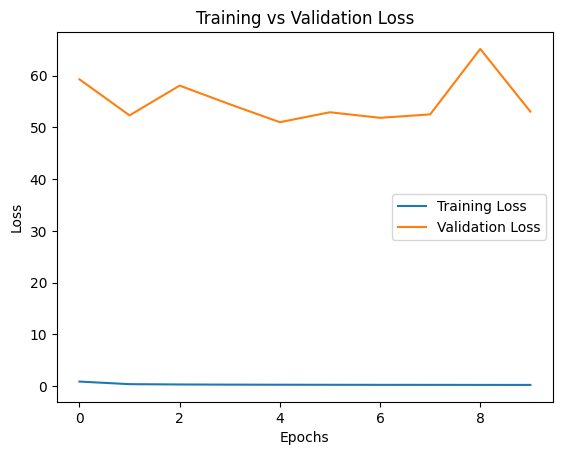

In [ ]:
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


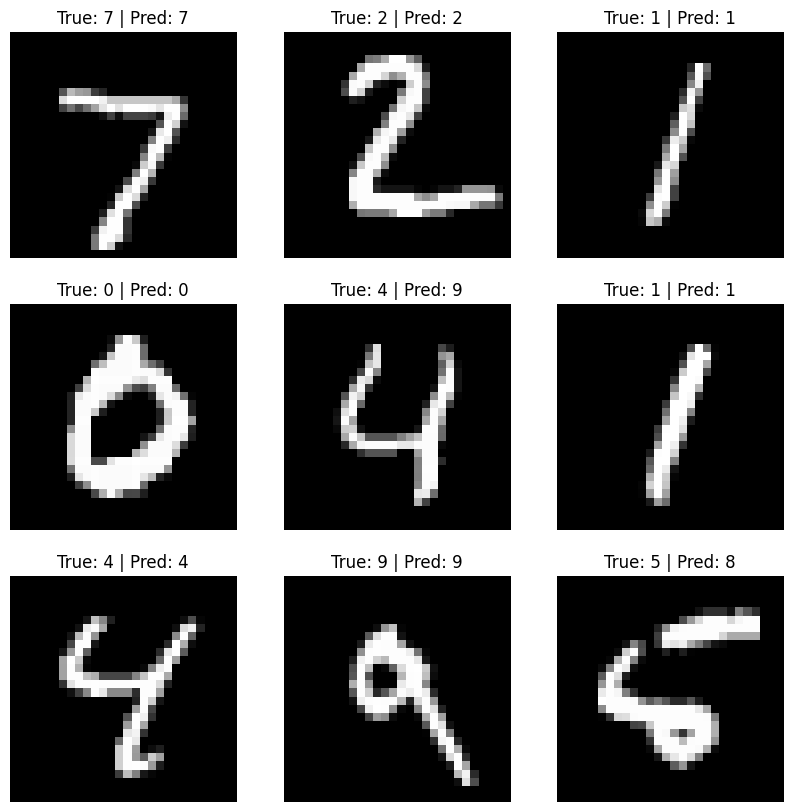

In [ ]:
predictions = model.predict(x_test_f)
predicted_labels = predictions.argmax(axis=1)

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"True: {y_test[i]} | Pred: {predicted_labels[i]}")
    plt.axis('off')
plt.show()


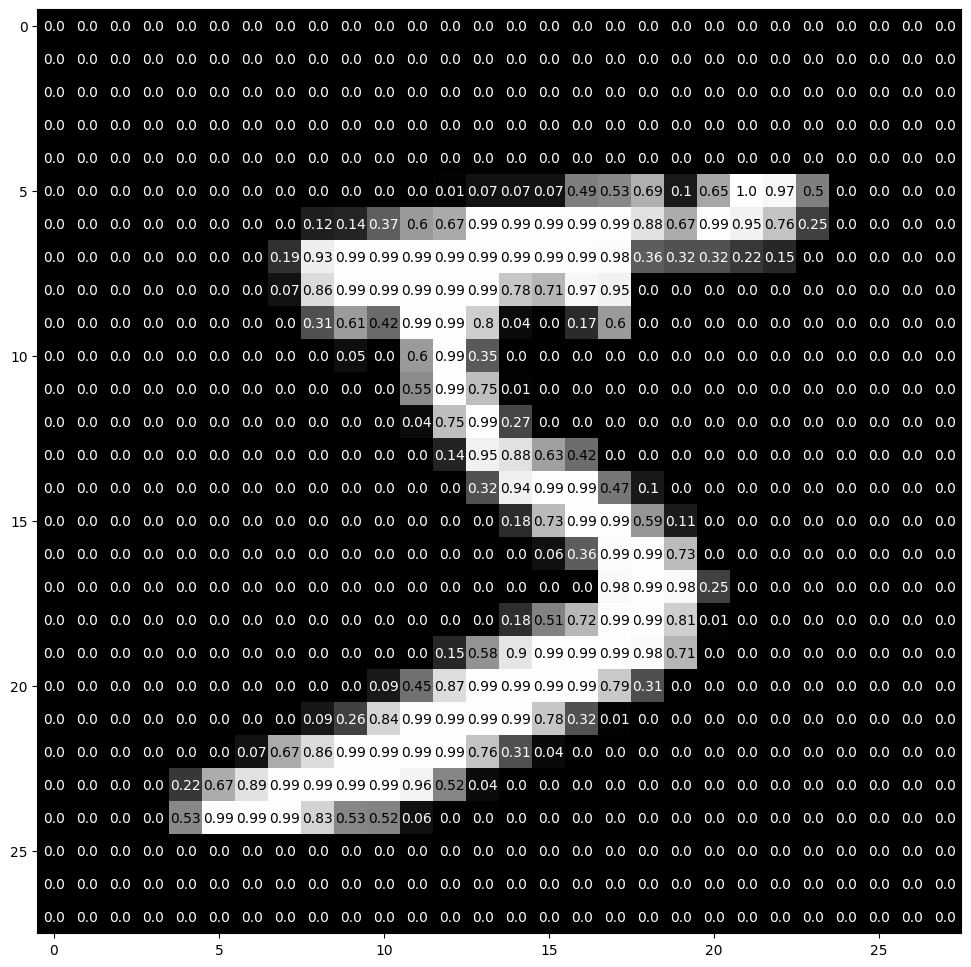

In [ ]:
def visualize_input(img, ax):
    ax.imshow(img, cmap='gray')
    width, height = img.shape
    thresh = img.max()/2.5
    for x in range(width):
        for y in range(height):
            ax.annotate(str(round(img[x][y],2)), xy=(y,x),
                        horizontalalignment='center',
                        verticalalignment='center',
                        color='white' if img[x][y]<thresh else 'black')

fig = plt.figure(figsize = (12,12))
ax = fig.add_subplot(111)
visualize_input(x_train[0], ax)